In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

# 1. Cleaning Data

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
print("--- INSURANCE DATA ---")
df.info()

--- INSURANCE DATA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# check duplicated rows
print(df[df.duplicated(keep=False)])


     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


In [5]:
# checking unique values in categorical columns
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [6]:
## Delete the duplicate rows
# Remove duplicate rows and keep only the first occurrence
df = df.drop_duplicates()

# Verify that the duplicate is gone
print(f"New dataset shape: {df.shape}")

New dataset shape: (1337, 7)


In [7]:
# checking value counts in categorical columns
sex = df['sex'].value_counts()
print(sex)
print("Total:", sum(sex))
print("--------------------------")

smoker = df['smoker'].value_counts()
print(smoker)
print("Total:", sum(smoker))
print("--------------------------")

region = df['region'].value_counts()
print(region)
print("Total:", sum(region))

sex
male      675
female    662
Name: count, dtype: int64
Total: 1337
--------------------------
smoker
no     1063
yes     274
Name: count, dtype: int64
Total: 1337
--------------------------
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
Total: 1337


# EDA

In [8]:
# 1. SUMMARY STATISTICS

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print(df.dtypes)

print("\n--- Numeric Summary ---")
print(df.describe().round(2))

print("\n--- Categorical Counts ---")
for col in ["sex", "smoker", "region"]:
    print(f"\n{col}:\n{df[col].value_counts()}")

print("\n--- Missing Values ---")
print(df.isnull().sum())

DATASET OVERVIEW
Shape: 1337 rows × 7 columns

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

--- Numeric Summary ---
           age      bmi  children   charges
count  1337.00  1337.00   1337.00   1337.00
mean     39.22    30.66      1.10  13279.12
std      14.04     6.10      1.21  12110.36
min      18.00    15.96      0.00   1121.87
25%      27.00    26.29      0.00   4746.34
50%      39.00    30.40      1.00   9386.16
75%      51.00    34.70      2.00  16657.72
max      64.00    53.13      5.00  63770.43

--- Categorical Counts ---

sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

--- Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
ch

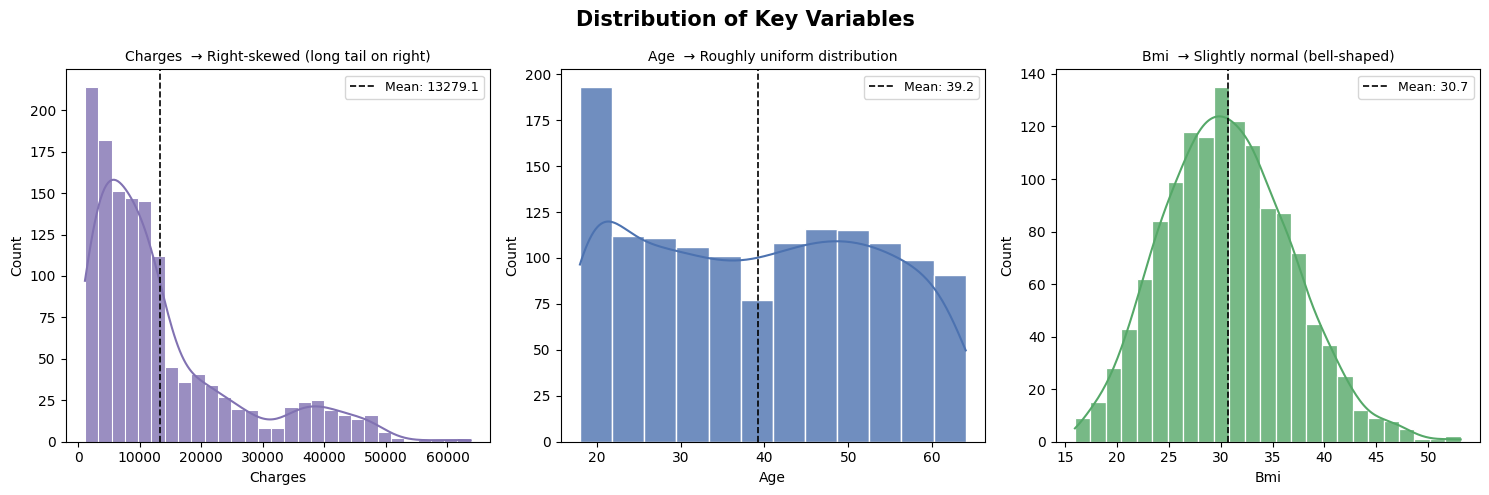

In [9]:
# 2. HISTOGRAMS — Distribution of Numeric Variables

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribution of Key Variables", fontsize=15, fontweight="bold")

hist_cols  = ["charges", "age", "bmi"]
hist_colors = ["#8172B2", "#4C72B0", "#55A868"]
hist_notes  = ["→ Right-skewed (long tail on right)",
               "→ Roughly uniform distribution",
               "→ Slightly normal (bell-shaped)"]

for ax, col, color, note in zip(axes, hist_cols, hist_colors, hist_notes):
    sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor="white", alpha=0.8)
    mean_val = df[col].mean()
    ax.axvline(mean_val, color="black", linestyle="--", linewidth=1.2,
               label=f"Mean: {mean_val:.1f}")
    ax.set_title(f"{col.capitalize()}  {note}", fontsize=10)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

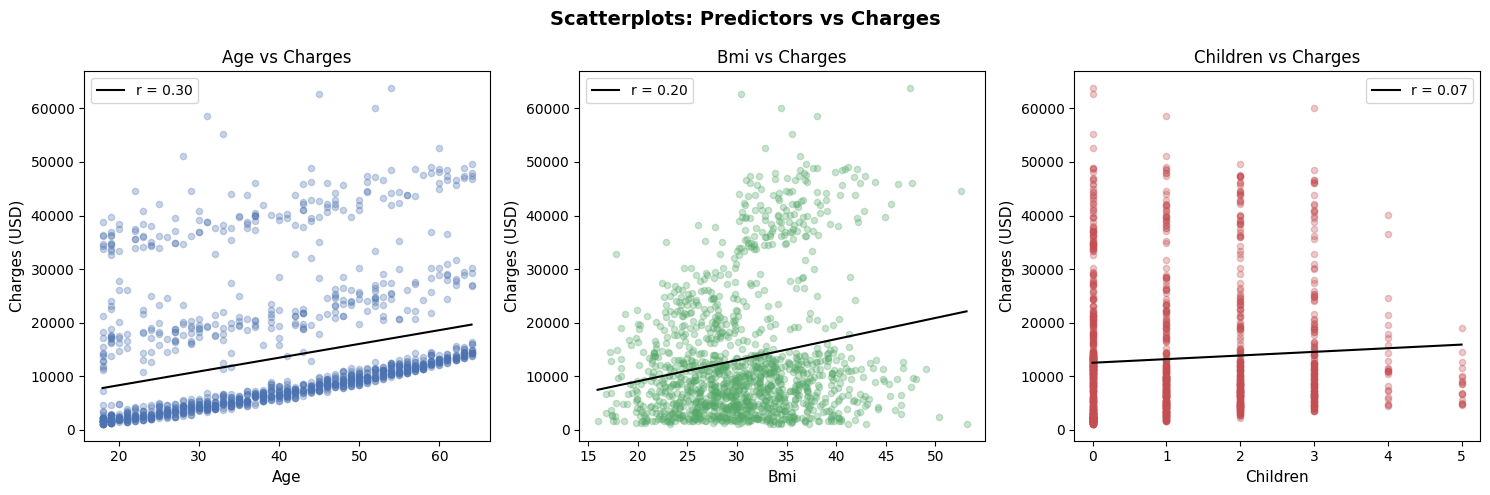

In [10]:
# 3. SCATTERPLOTS — Predictors vs Charges

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Scatterplots: Predictors vs Charges", fontsize=14, fontweight="bold")

scatter_cols = ["age", "bmi", "children"]
colors_s = ["#4C72B0", "#55A868", "#C44E52"]

for ax, col, color in zip(axes, scatter_cols, colors_s):
    ax.scatter(df[col], df["charges"], alpha=0.3, color=color, s=20)
    # Trend line
    m, b, r, p, _ = stats.linregress(df[col], df["charges"])
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_range, m * x_range + b, color="black", linewidth=1.5,
            label=f"r = {r:.2f}")
    ax.set_xlabel(col.capitalize(), fontsize=11)
    ax.set_ylabel("Charges (USD)", fontsize=11)
    ax.set_title(f"{col.capitalize()} vs Charges", fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

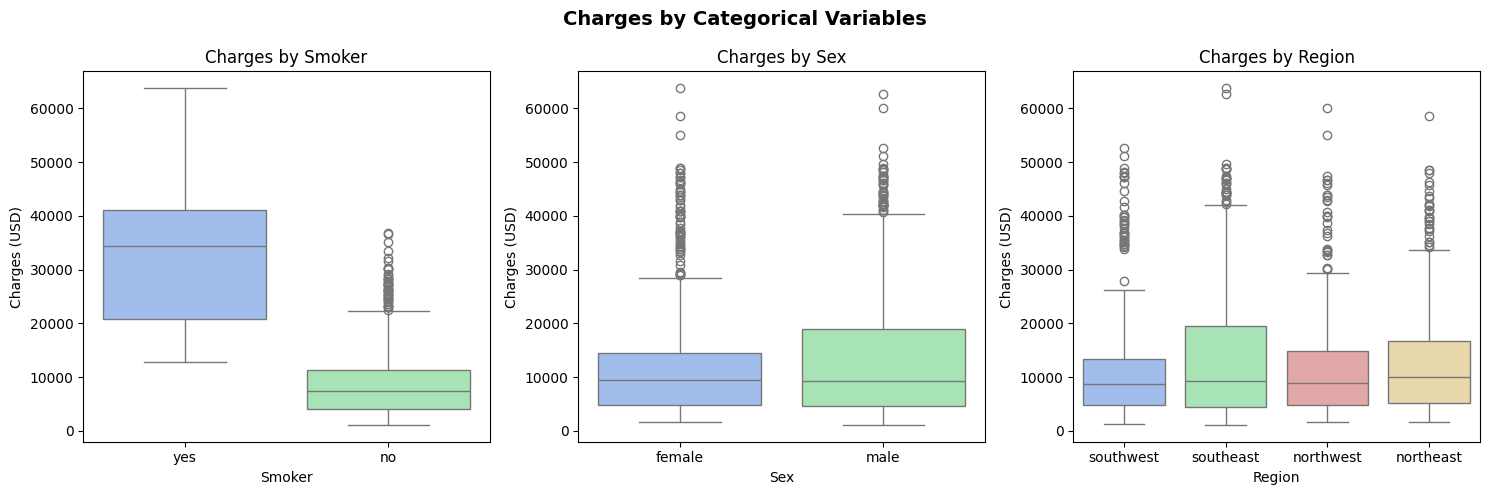

In [11]:
# 4. BOXPLOTS — Categorical Variables vs Charges

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Charges by Categorical Variables", fontsize=14, fontweight="bold")

cat_cols = ["smoker", "sex", "region"]
palette = ["#93BAF9", "#9EEDB1", "#EC9D9F", "#F3DDA2"]

for ax, col in zip(axes, cat_cols):
    sns.boxplot(data=df, x=col, y="charges", ax=ax,
                hue=col, palette=palette[:df[col].nunique()], legend=False)
    ax.set_title(f"Charges by {col.capitalize()}", fontsize=12)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel("Charges (USD)")

plt.tight_layout()
plt.show()


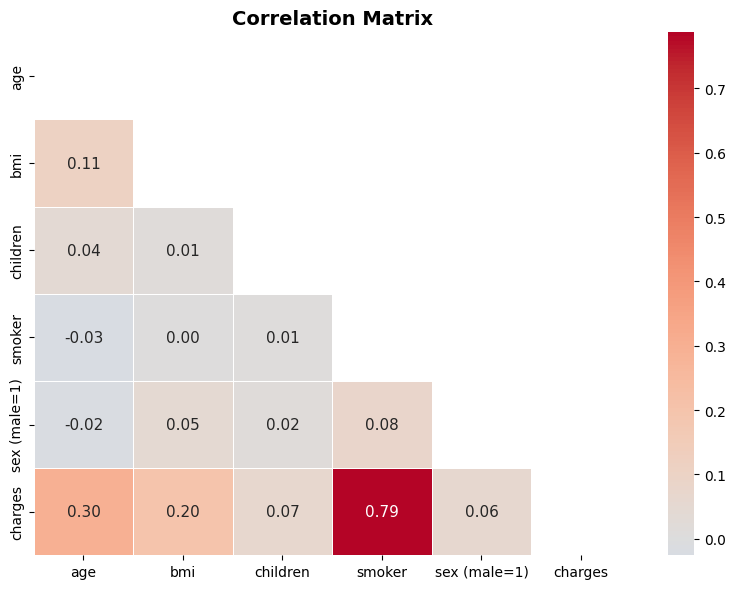

In [12]:
# 5. CORRELATION MATRIX

# Encode binary categoricals for correlation
df_corr = df.copy()
df_corr["smoker_enc"] = (df["smoker"] == "yes").astype(int)
df_corr["sex_enc"]    = (df["sex"] == "male").astype(int)

corr_cols = ["age", "bmi", "children", "smoker_enc", "sex_enc", "charges"]
corr_matrix = df_corr[corr_cols].corr()

# Rename labels for readability
label_map = {"smoker_enc": "smoker", "sex_enc": "sex (male=1)"}
corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 11})
ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

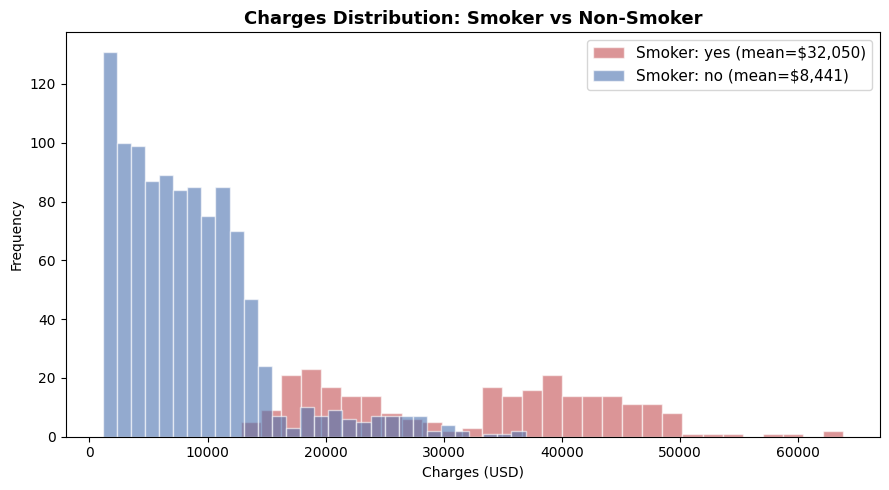

In [13]:
# 6. SMOKER BREAKDOWN — Charges Distribution

fig, ax = plt.subplots(figsize=(9, 5))
for label, color in zip(["yes", "no"], ["#C44E52", "#4C72B0"]):
    subset = df[df["smoker"] == label]["charges"]
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label=f"Smoker: {label} (mean=${subset.mean():,.0f})",
            edgecolor="white")
ax.set_title("Charges Distribution: Smoker vs Non-Smoker", fontsize=13, fontweight="bold")
ax.set_xlabel("Charges (USD)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Visualizing Hidden Structures:

In our preliminary analysis, simple scatterplots showed only moderate or weak correlations (Age r=0.30, BMI r=0.20). However, these numbers can be misleading if the relationship is conditional. We use hue (Smoking Status) and size (BMI) in the following plots to determine if these variables interact, meaning the effect of one variable depends on the state of another.

### 1. Age vs Smoker vs BMI vs Charges

Investigate if the price jump in insurance is constant or if it creates distinct risk tiers as individuals age

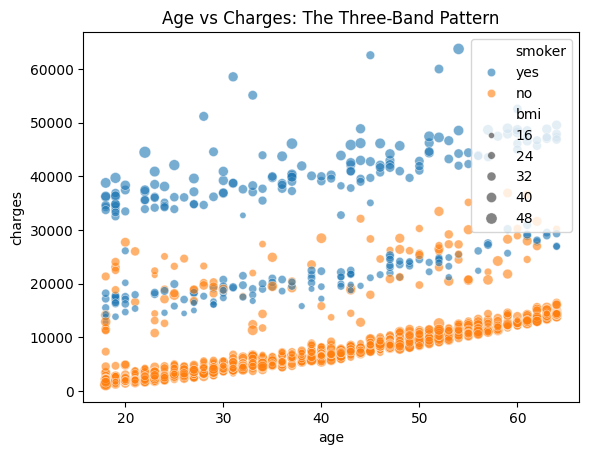

In [14]:
# Three-Band Evidence
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', size='bmi', alpha=0.6)
plt.title("Age vs Charges: The Three-Band Pattern")
plt.show()

The visualization confirms three distinct horizontal bands, validating that the relationship between age and cost is not a single uniform cloud.

#### 2. BMI vs Smoker vs Charges

A key finding in our correlation matrix is the zero correlation (r = 0.00) between BMI and Smoking Status. This indicates that these two variables are statistically independent—knowing an individual's BMI provides no information about their smoking habits. However, while they are independent of each other, they are not independent in their effect on Charges. The scatterplot analysis reveals a hidden relationship

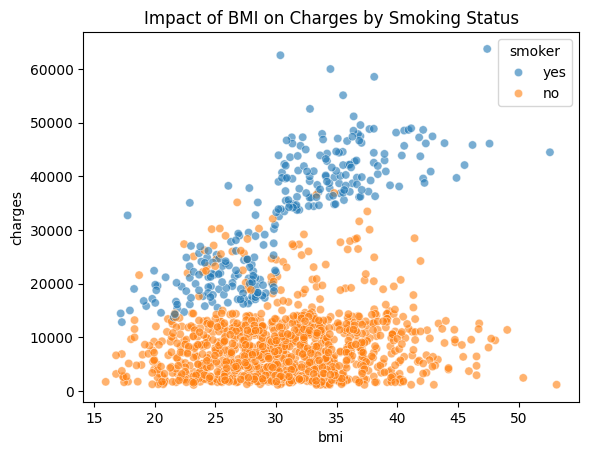

In [15]:
# Two-Slope Evidence (BMI vs Smoking vs Charges)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title("Impact of BMI on Charges by Smoking Status")
plt.show()

The scatterplot reveals a hidden relationship that the correlation matrix misses. While BMI and Smoking status are statistically independent (r = 0.00), they may exhibit a strong synergistic effect on medical charges. Smoking status acts as a catalyst; for non-smokers, BMI has a negligible impact, but for smokers, high BMI triggers an exponential surge in costs.

# 4. Inference Component

### Separate Groups

The dataset is divided into two independent groups based on smoking status: smokers and non-smokers. Only the insurance charges variable is selected for comparison.

In [16]:
smoker     = df[df["smoker"] == "yes"]["charges"]
non_smoker = df[df["smoker"] == "no"]["charges"]

### Descriptive Statistics

This step calculates the mean charges for each group and provides an initial comparison. It helps identify whether there is a noticeable difference between smokers and non-smokers before performing statistical tests.

In [17]:
print("=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)

print(f"Smoker mean    : ${smoker.mean():,.2f}")
print(f"Non-smoker mean: ${non_smoker.mean():,.2f}")
print(f"Sample sizes   : smoker={len(smoker)}, non-smoker={len(non_smoker)}")
print(f"Mean difference: ${(smoker.mean() - non_smoker.mean()):,.2f}")

DESCRIPTIVE STATISTICS
Smoker mean    : $32,050.23
Non-smoker mean: $8,440.66
Sample sizes   : smoker=274, non-smoker=1063
Mean difference: $23,609.57


### Hypothesis Testing (Welch’s t-test)

An independent two-sample t-test (Welch’s t-test) is used to determine whether the mean charges of smokers and non-smokers are significantly different. The test does not assume equal variances between the two groups and is appropriate for comparing independent samples.

In [18]:
alpha = 0.05

print("\n" + "=" * 50)
print("HYPOTHESIS TESTING (Welch's Two-Sample t-test)")
print("=" * 50)

print("H0: Mean charges (smoker) = Mean charges (non-smoker)")
print("H1: Mean charges (smoker) ≠ Mean charges (non-smoker)")
print("Test type: Two-sided")
print(f"Significance level (alpha): {alpha}")

t_stat, p_value = stats.ttest_ind(smoker, non_smoker, equal_var=False)

print(f"\nT-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.2e}")

print("\n--- Decision ---")
if p_value < alpha:
    print("p-value < alpha → Reject H0")
else:
    print("p-value ≥ alpha → Fail to reject H0")

print("\n--- Interpretation ---")
print("There is strong statistical evidence that the mean insurance charges")
print("for smokers are different from those of non-smokers.")
print("In this sample, smokers have much higher charges on average.")


HYPOTHESIS TESTING (Welch's Two-Sample t-test)
H0: Mean charges (smoker) = Mean charges (non-smoker)
H1: Mean charges (smoker) ≠ Mean charges (non-smoker)
Test type: Two-sided
Significance level (alpha): 0.05

T-statistic : 32.7423
P-value     : 6.26e-103

--- Decision ---
p-value < alpha → Reject H0

--- Interpretation ---
There is strong statistical evidence that the mean insurance charges
for smokers are different from those of non-smokers.
In this sample, smokers have much higher charges on average.


### Confidence Interval (Welch’s t-based)

A 95% confidence interval is constructed to estimate the range in which the true difference in mean charges is likely to lie. If the interval does not include zero, it indicates a statistically significant difference between the two groups.

In [19]:
print("\n" + "=" * 50)
print("95% CONFIDENCE INTERVAL (Mean Difference)")
print("=" * 50)

mean_diff = smoker.mean() - non_smoker.mean()

# Standard Error
se = np.sqrt(
    smoker.var(ddof=1) / len(smoker) +
    non_smoker.var(ddof=1) / len(non_smoker)
)

# Welch's degrees of freedom
df_welch = (
    (smoker.var(ddof=1)/len(smoker) +
     non_smoker.var(ddof=1)/len(non_smoker))**2
) / (
    ((smoker.var(ddof=1)/len(smoker))**2 / (len(smoker) - 1)) +
    ((non_smoker.var(ddof=1)/len(non_smoker))**2 / (len(non_smoker) - 1))
)

# Critical value
t_crit = stats.t.ppf(0.975, df=df_welch)

# CI
ci_low  = mean_diff - t_crit * se
ci_high = mean_diff + t_crit * se

print(f"Mean Difference (smoker - non-smoker): ${mean_diff:,.2f}")
print(f"Standard Error                       : ${se:,.2f}")
print(f"Degrees of Freedom (Welch)           : {df_welch:.2f}")
print(f"t* (critical value)                  : {t_crit:.4f}")
print(f"95% CI: [${ci_low:,.2f}, ${ci_high:,.2f}]")

print("\n--- Interpretation ---")
print("We are 95% confident that the true difference in mean charges")
print("lies within this interval.")
print("Since 0 is not in the interval → statistically significant difference.")


95% CONFIDENCE INTERVAL (Mean Difference)
Mean Difference (smoker - non-smoker): $23,609.57
Standard Error                       : $721.07
Degrees of Freedom (Welch)           : 311.88
t* (critical value)                  : 1.9676
95% CI: [$22,190.79, $25,028.35]

--- Interpretation ---
We are 95% confident that the true difference in mean charges
lies within this interval.
Since 0 is not in the interval → statistically significant difference.


### Assumptions

In [20]:
print("\n" + "=" * 50)
print("ASSUMPTIONS")
print("=" * 50)

print("1. Observations are independent.")
print("2. Two groups are independent.")
print("3. Large sample sizes → t-approximation is valid.")


ASSUMPTIONS
1. Observations are independent.
2. Two groups are independent.
3. Large sample sizes → t-approximation is valid.


In [21]:
summary_df = pd.DataFrame({
    "Method": ["Hypothesis Test", "Confidence Interval"],
    "Result": [
        f"{'Reject H0' if p_value < 0.05 else 'Fail to reject H0'} (p = {p_value:.2e})",
        f"[{ci_low:,.0f}, {ci_high:,.0f}]"
    ]
})

print("\nINFERENCE SUMMARY")
print(summary_df.to_string(index=False))


INFERENCE SUMMARY
             Method                    Result
    Hypothesis Test Reject H0 (p = 6.26e-103)
Confidence Interval          [22,191, 25,028]


Cohen’s d is calculated to measure the magnitude of the difference between the two groups. Unlike the p-value, which indicates statistical significance, the effect size shows how large the difference is in practical terms.

In [22]:
pooled_std = np.sqrt((smoker.var(ddof=1) + non_smoker.var(ddof=1)) / 2)
cohen_d = (smoker.mean() - non_smoker.mean()) / pooled_std

print(f"\nEffect Size (Cohen's d): {cohen_d:.2f}")


Effect Size (Cohen's d): 2.57


# **Interpretation**

### A. Hypothesis Testing (Welch’s t-test)

**Hypotheses**

* H₀: μ_smoker = μ_non-smoker
* H₁: μ_smoker ≠ μ_non-smoker

**Statistical Decision**
The p-value (6.26 × 10⁻¹⁰³) is less than the significance level (α = 0.05).
Therefore, we **reject H₀**.

**Interpretation**
There is sufficient statistical evidence to conclude that smoking status significantly affects medical charges. Smokers have a much higher average cost ($32,050) compared to non-smokers ($8,434).


### B. Confidence Interval (95% CI)

**Result**
95% CI for the mean difference: [$22,190.79 , $25,028.35]

**Interpretation**
We are 95% confident that the true difference in mean medical charges between smokers and non-smokers lies within this interval. Since the interval does not include 0, it confirms that the difference is statistically significant.

This means smokers are expected to pay at least around $22,000–$25,000 more than non-smokers on average.


### C. Practical Significance (Effect Size)

**Result**
Cohen’s d = 2.57

**Interpretation**
A value greater than 0.8 is considered a large effect. Therefore, a value of 2.57 indicates a **very large effect size**.

This shows that the difference is not only statistically significant but also practically important. Smoking has a strong impact on increasing medical insurance costs.


### Conclusion on Hypothesis Testing (Welch’s t-test) & Practical Significance (Effect Size)

An independent two-sample t-test (Welch’s t-test) was conducted to compare the mean insurance charges between smokers and non-smokers.

Since the p-value is less than 0.05, we reject the null hypothesis (H₀) and conclude that there is a statistically significant difference in mean charges between the two groups (μ_smoker ≠ μ_non-smoker).

The confidence interval supports this result, and the large effect size (Cohen’s d = 2.57) indicates that the difference is practically meaningful.

Overall, smoking is a major factor associated with higher medical insurance costs.

# 5.Modeling Component (response: Charges)

This section develops regression models to quantify the relationship between medical insurance charges and key predictors. Following the findings in the exploratory and inference phases, we establish a baseline with a simple model and then expand to a more comprehensive multiple regression analysis.

### Model A: Simple Linear Regression (predictor: Smoker)

Based on the high correlation (r = 0.79) from correlation matrix and the statistically significant difference found in the Welch’s t-test, smoker status is selected as the primary predictor for the model.

Model Equation: $Charges = \beta_0 + \beta_1(Smoker)$

In [ ]:
# Note: smoker_enc is used here (1 for yes, 0 for no)
df['smoker_enc'] = (df['smoker'] == 'yes').astype(int)
y = df['charges']
X_a = sm.add_constant(df['smoker_enc'])

# Fit the simple linear model
model_a = sm.OLS(y, X_a).fit()

In [ ]:
# Function to format the equation string
def get_equation(model, model_name, predictors):
    b0 = model.params['const']
    coeffs = [f"{model.params[pred]:.2f}({pred})" for pred in predictors]
    equation = f"{model_name}: Charges = {b0:.2f} + " + " + ".join(coeffs)
    return equation

# Print the equations
print(get_equation(model_a, "Model A", ['smoker_enc']))

Model A: Charges = 8440.66 + 23609.57(smoker_enc)


#### Interpretation:
- Slope b_1 = 23609.57: For an individual who is a smoker ($\text{smoker\_enc} = 1$), the predicted insurance charges increase by about $23,609.57 compared to a non-smoker.

- Intercept b_0 = 8440.66: If a person is a non-smoker ($\text{smoker\_enc} = 0$), they are predicted to have insurance charges of $8,440.66.

### Model B: Multiple Linear Regression (predictor: Smoker, Age)

Model Equation: $Charges = \beta_0 + \beta_1(Smoker) + \beta_2(Age)$

In [ ]:
# Define multiple predictors: Smoker, Age
X_b = df[['smoker_enc', 'age']]
X_b = sm.add_constant(X_b)

# Fit the multiple regression model
model_b = sm.OLS(y, X_b).fit()

# Print the equations
print(get_equation(model_b, "Model B", ['smoker_enc', 'age']))

Model B: Charges = -2386.87 + 23854.10(smoker_enc) + 274.78(age)


#### Interpretation:

- Slope b_1 ($\text{Smoker}$) = 23854.10: Holding age constant, being a smoker increases the predicted insurance charges by $23,854.10 on average.

- Slope b_2 ($\text{Age}$) = 274.78: For each additional year of age, the predicted insurance charges increase by $274.78, assuming the smoking status remains the same.

- Intercept b_0 = -2386.87: If a person is a non-smoker and has an age of 0, they are predicted to have charges of -$2,386.87.

### Model C: Multiple Linear Regression (predictor: Smoker, Age, Bmi)

Model Equation: $Charges = \beta_0 + \beta_1(Smoker) + \beta_2(Age) + \beta_3(Bmi)$

In [ ]:
# We include BMI to capture the hidden effect discussed in EDA
X_c = df[['smoker_enc', 'age', 'bmi']]
X_c = sm.add_constant(X_c)

# Fit the multiple regression model
model_c = sm.OLS(y, X_c).fit()

# Print the equations
print(get_equation(model_c, "Model C", ['smoker_enc', 'age', 'bmi']))

Model C: Charges = -11671.69 + 23822.18(smoker_enc) + 259.43(age) + 322.64(bmi)


#### Interpretation of Coefficients
- Slope $b_1 (\text{Smoker}) = 23822.18$: Holding age and BMI constant, being a smoker increases the predicted charges by $23,822.18.

- Slope $b_2 (\text{Age}) = 259.43$: For each additional year of age, the predicted charges increase by $259.43, holding smoking status and BMI constant.

- Slope $b_3 (\text{BMI}) = 322.64$: For each one-unit increase in BMI, the predicted charges increase by $322.64, holding smoking status and age constant.

- Intercept $b_0 = -11671.69$: If a person is a non-smoker, 0 years old, and has a BMI of 0, the predicted charges are -$11,671.69.

### Identifying Important Variables
Most Important: Smoker Status is the most critical variable because it has the largest coefficient. It creates a massive jump in cost that is significantly higher than the impact of age or BMI.

Significant Predictors: Both Age and BMI are also important as they capture the cost tiers discovered in the EDA. BMI is especially vital for identifying high-risk individuals in the smoker group.

### Model Comparison

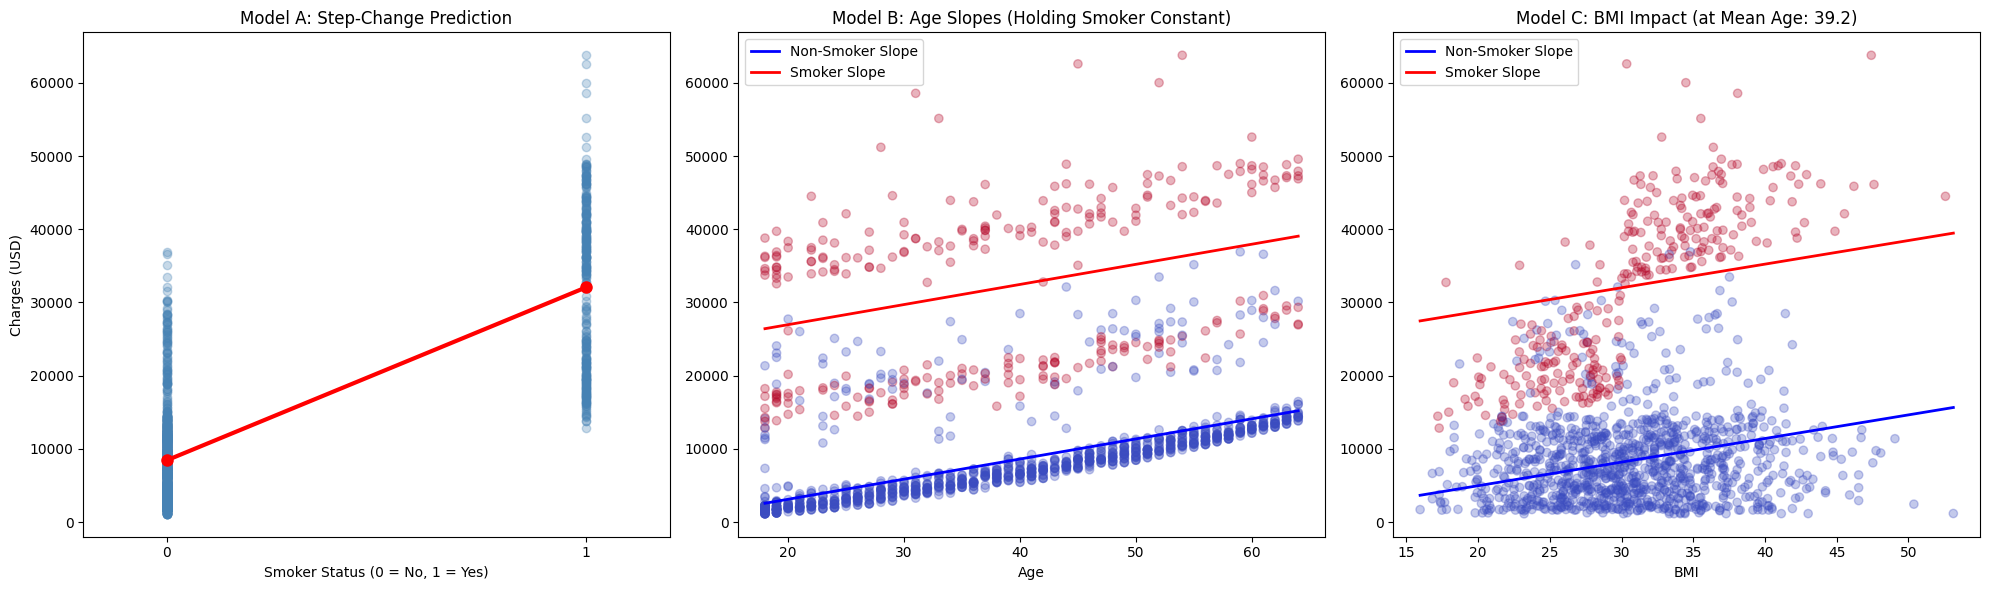

In [ ]:
# 1. Setup figure and data ranges for the lines
# We use the actual min/max from the cleaned dataset for the x-axis limits
age_range = np.linspace(df['age'].min(), df['age'].max(), 100)
bmi_range = np.linspace(df['bmi'].min(), df['bmi'].max(), 100)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- MODEL A: Smoker (Binary) vs Charges ---
# Scatter real data points (smoker_enc is 0 or 1)
axes[0].scatter(df['smoker_enc'], df['charges'], alpha=0.3, color='steelblue')

# Plot the trained line connecting predicted means for 0 and 1
# This represents the "Step-Change" found by the model
pred_a = model_a.predict(sm.add_constant([0, 1]))
axes[0].plot([0, 1], pred_a, color='red', marker='o', markersize=8, linewidth=3, label='Trained Line')

axes[0].set_title("Model A: Step-Change Prediction")
axes[0].set_xlabel("Smoker Status (0 = No, 1 = Yes)")
axes[0].set_ylabel("Charges (USD)")

# FORCE INTEGER TICKS: Ensure axis shows exactly 0 and 1
axes[0].set_xticks([0, 1])
axes[0].set_xlim(-0.2, 1.2) # Add padding so points aren't cut off

# --- MODEL B: Age vs Charges (Grouped by Smoker) ---
# Scatter points colored by smoker status
axes[1].scatter(df['age'], df['charges'], c=df['smoker_enc'], cmap='coolwarm', alpha=0.3)

# Calculate lines using Model B coefficients: b0 + b1(smoker) + b2(age)
line_b_no = model_b.params['const'] + model_b.params['age'] * age_range
line_b_yes = model_b.params['const'] + model_b.params['smoker_enc'] + model_b.params['age'] * age_range

axes[1].plot(age_range, line_b_no, color='blue', linewidth=2, label='Non-Smoker Slope')
axes[1].plot(age_range, line_b_yes, color='red', linewidth=2, label='Smoker Slope')

axes[1].set_title("Model B: Age Slopes (Holding Smoker Constant)")
axes[1].set_xlabel("Age")
axes[1].legend()

# --- MODEL C: BMI vs Charges (Grouped by Smoker) ---
# We fix Age at its mean value to visualize the impact of BMI alone
avg_age = df['age'].mean()
axes[2].scatter(df['bmi'], df['charges'], c=df['smoker_enc'], cmap='coolwarm', alpha=0.3)

# Calculate lines using Model C coefficients: b0 + b1(smoker) + b2(age) + b3(bmi)
line_c_no = model_c.params['const'] + (model_c.params['age'] * avg_age) + (model_c.params['bmi'] * bmi_range)
line_c_yes = model_c.params['const'] + model_c.params['smoker_enc'] + (model_c.params['age'] * avg_age) + (model_c.params['bmi'] * bmi_range)

axes[2].plot(bmi_range, line_c_no, color='blue', linewidth=2, label='Non-Smoker Slope')
axes[2].plot(bmi_range, line_c_yes, color='red', linewidth=2, label='Smoker Slope')

axes[2].set_title(f"Model C: BMI Impact (at Mean Age: {avg_age:.1f})")
axes[2].set_xlabel("BMI")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 1. Helper function to calculate all requested metrics
def get_model_metrics(model, X, y):
    predictions = model.predict(X)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = model.rsquared
    adj_r2 = model.rsquared_adj
    return [r2, adj_r2, mse, rmse]

# 2. Compile results into a DataFrame
comparison_data = {
    "Metric": ["R-squared", "Adj. R-squared", "MSE", "RMSE"],
    "Model A (Smoker)": get_model_metrics(model_a, X_a, y),
    "Model B (Smoker + Age)": get_model_metrics(model_b, X_b, y),
    "Model C (Smoker + Age + BMI)": get_model_metrics(model_c, X_c, y)
}

df_compare = pd.DataFrame(comparison_data).set_index("Metric")
print("--- Model Comparison Table ---")
print(df_compare.round(4))

--- Model Comparison Table ---
                Model A (Smoker)  Model B (Smoker + Age)  \
Metric                                                     
R-squared           6.197000e-01            7.212000e-01   
Adj. R-squared      6.195000e-01            7.208000e-01   
MSE                 5.572783e+07            4.085617e+07   
RMSE                7.465107e+03            6.391883e+03   

                Model C (Smoker + Age + BMI)  
Metric                                        
R-squared                       7.473000e-01  
Adj. R-squared                  7.467000e-01  
MSE                             3.703142e+07  
RMSE                            6.085345e+03  


#### R2 and Adjusted R2nterpretation:
Model A (R2: 0.6197, Adj R2: 0.6195): This baseline model explains approximately 62% of the variance in charges using only smoking status.
Model B (R2: 0.7212, Adj R2: 0.7208): Adding age significantly improves the explanatory power by 10%.
Model C (R2: 0.7473, Adj R2: 0.7467): This model achieves the highest Adjusted R2, confirming that BMI and Age provides unique information that improves the fit.

Conclusion: The consistent increase in Adjusted R2 proves that each added predictor is statistically justified and helps the model capture real patterns rather than noise.

#### Prediction Error Evaluation (RMSE) interpretation:
Model A (RMSE: 7,465.11): This model has the highest prediction error, as it ignores biological factors like age and health status.
Model B (RMSE: 6,391.88): The error drops by over $1,000, indicating that predictions are becoming closer to actual charges.
Model C (RMSE: 6,085.35): This model provides the lowest prediction error and the best accuracy for estimating costs.


Conclusion:  While an RMSE of $6,085 is high relative to the mean ($13,270.42) and median ($9,382.03), the reduction of $1,380 in total error from Model A to C can justify the final model choice.

### Model Evaluation: Residual Analysis

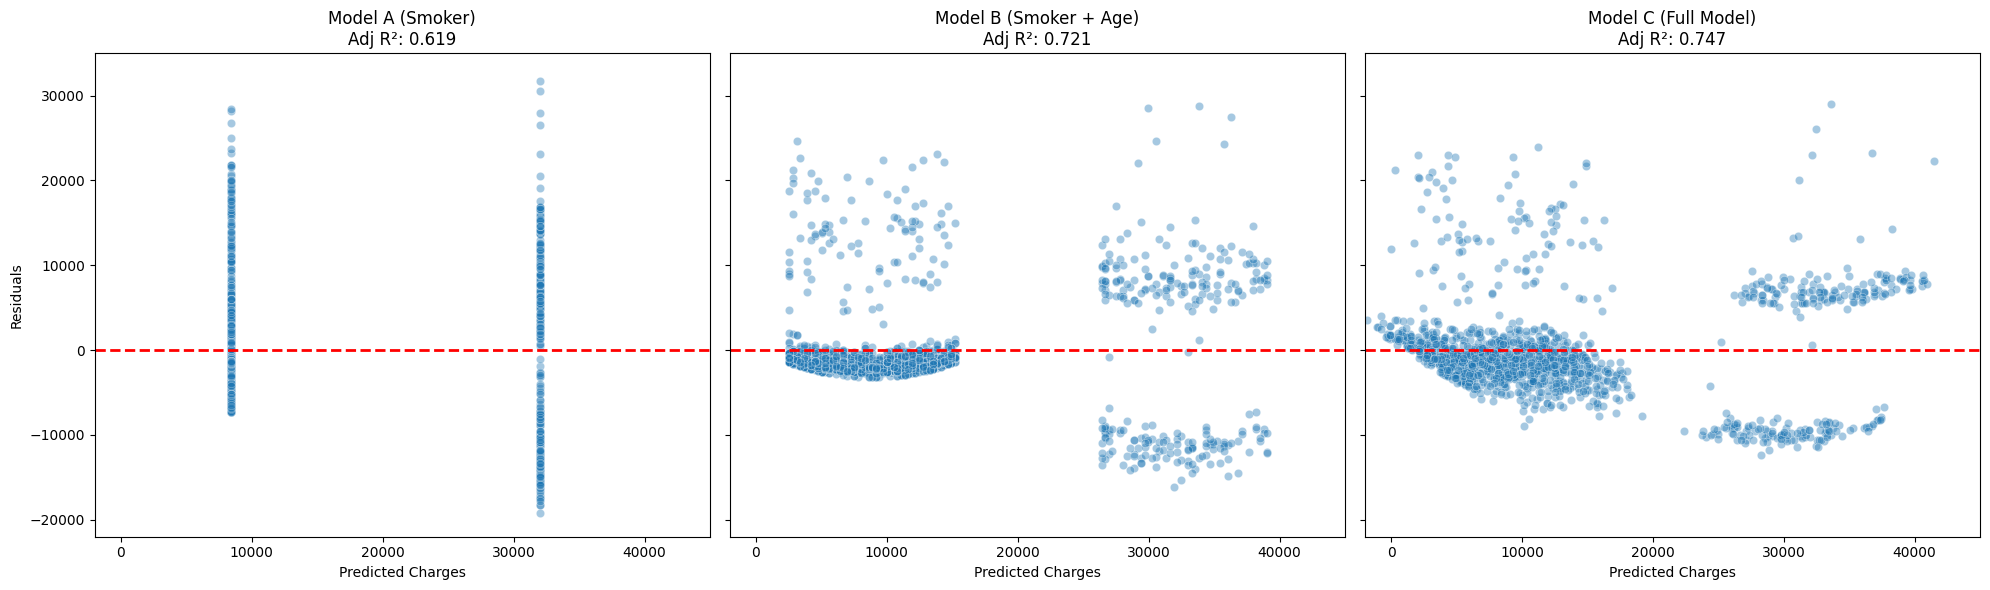

In [ ]:
# Predicted values (X-axis) go up to ~45k, Residuals (Y-axis) go ~ -20k to +35k
x_limit = (-2000, 45000)
y_limit = (-22000, 35000)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

models = [
    (model_a, "Model A (Smoker)", axes[0]),
    (model_b, "Model B (Smoker + Age)", axes[1]),
    (model_c, "Model C (Full Model)", axes[2])
]

for model, title, ax in models:
    sns.scatterplot(x=model.fittedvalues, y=model.resid, ax=ax, alpha=0.4)
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_title(f"{title}\nAdj R²: {model.rsquared_adj:.3f}")
    ax.set_xlabel("Predicted Charges")
    ax.set_ylabel("Residuals")

    # Apply the same scale to all plots
    ax.set_xlim(x_limit)
    ax.set_ylim(y_limit)

plt.tight_layout()
plt.show()


- Model A (Underfit): The residuals show distinct vertical clusters and a clear trend, indicating High Bias. This model is too simple as it only accounts for smoking status, failing to explain the variance within the smoking and non-smoking groups.


- Model B (Incremental Fit): By adding age, the residuals begin to spread across the horizontal axis, showing that the model is now capturing the upward trend in costs over time. However, there are still significant gaps and clusters, suggesting that a key health predictor may be still missing.


- Model C (Better Fit): This model shows the most balanced distribution around the zero line. However, it displays clear heteroscedasticity, where the error variance increases or shifts in specific regions of the predicted values. While the model captures the primary underlying patterns, the systematic grouping of residuals indicates that the model's accuracy varies across different cost levels.

# **Conclusion**

## The final selected model is Model C.

Justification: Model C is the superior choice because it provides the lowest prediction error (RMSE: $6,085.35) and the highest Adjusted  R2 (0.7467).


Meaningful Improvement: The jump in performance from Model A to Model B to Model C confirms that BMI and Age is a necessary predictor. It also captures the synergistic risk where high BMI combined with smoking triggers an exponential surge in charges.


Balance: Despite being the most complex model, it remains highly interpretable with three clear factors that effectively explain the insurance pricing observed in the real world.


## Limitations & Assumptions

Normality and Symmetry: While Model C shows the best symmetry among the candidates, systematic grouping suggests the model may be systematically wrong in predicting high-cost outliers compared to baseline charges. Because the original charges were right-skewed, the residuals inherit this skewness.


Heteroscedasticity: The uneven spread in the residual plot indicates non-constant variance. This suggests prediction error is higher for high-cost smokers than for low-cost non-smokers, meaning model reliability varies across data segments.


Association vs. Causation: While a strong statistical relationship exists, especially between smoking status and charges (r = 0.79), these are correlations and do not strictly prove that smoking causes the specific dollar amount increase.


Extrapolation: The model is built on a specific range (e.g., ages 18–64). It should not be used to predict charges for attributes far outside the dataset range, such as BMI > 60 or Age > 100, as the linear relationship may no longer hold.


Omitted Variable Bias: Although the model includes key predictors, other factors not in the training set could lead to unexplained variance.